<a href="https://colab.research.google.com/github/Martin1421cl/mineria_datos/blob/main/Evaluacion1_CamposMerino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Martin Campos y Francisco Merino**



In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [81]:
#https://www.kaggle.com/datasets/saidaminsaidaxmadov/students-academic-performance-dataset
#link data que usamos

#**Contexto**
Este conjunto de datos contiene información sobre el rendimiento académico de los estudiantes en tres asignaturas: matemáticas, ciencias e inglés. También incluye varios factores demográficos y educativos que pueden influir en el rendimiento estudiantil, como el género, el nivel educativo de los padres, el tipo de almuerzo y la participación en un curso de preparación para exámenes.

El objetivo de este conjunto de datos es analizar cómo los diferentes factores afectan los resultados académicos de los estudiantes e identificar patrones en su rendimiento en las distintas asignaturas.

El conjunto de datos consta de 1000 registros de estudiantes, donde cada fila representa a un estudiante individual y cada columna representa una característica o puntuación específica.

# **Variables**

* Género: Indica si el estudiante es hombre o mujer.
* Nivel educativo de los padres: El nivel educativo más alto alcanzado por los padres del estudiante.

* Almuerzo: Tipo de almuerzo que recibe el estudiante (estándar o gratuito/reducido).

* Curso de preparación para exámenes: Indica si el estudiante completó un curso de preparación para exámenes.

* Puntuación de matemáticas: Puntuación del estudiante en matemáticas.

* Puntuación de ciencias: Puntuación del estudiante en ciencias.

* Puntuación de inglés: Calificación del estudiante en inglés.

* Nivel educativo de los padres: El nivel educativo más alto alcanzado por los padres del estudiante.

* Almuerzo: Tipo de almuerzo que recibe el estudiante (estándar o gratuito/reducido).

* Curso de preparación para exámenes: Indica si el estudiante completó un curso de preparación para exámenes.

#**Propósito del análisis**

El conjunto de datos se puede utilizar para:

1. Evaluar el rendimiento general del estudiante

2. Comparar los resultados entre diferentes grupos de estudiantes

3. Analizar el impacto de los cursos de preparación en las calificaciones de los exámenes

4. Identificar las asignaturas en las que los estudiantes obtienen mejores o peores resultados

5. Generar indicadores clave de rendimiento (KPI) relacionados con el desempeño estudiantil



In [82]:
pd.options.display.max_rows = 9999

In [83]:
df = pd.read_csv("/content/Performance_of_Stuednts.csv")

In [84]:
df.head(50)

,gender,race/group,parental education level,lunch,test prep course,math score,science score,english score
0,Female,Group 10,bachelor's degree,standard,none,66,72,74
1,Female,Group 20,some college,standard,completed,69,90,88
2,Female,Group 10,master's degree,standard,none,90,88,93
3,Male,Group 9,associate's degree,free/reduced,none,47,57,44
4,Male,Group 20,some college,standard,none,76,44,75
5,Female,Group 10,associate's degree,standard,none,71,83,78
6,Female,Group 10,some college,standard,completed,79,95,92
7,Male,Group 10,some college,free/reduced,none,40,43,39
8,Male,Group 8,high school,free/reduced,completed,64,64,67
9,Female,Group 10,high school,free/reduced,none,38,60,50


# Justificacion: podemos ver en la tabla todas las columnas y algunas filas de los datos que encontramos en la data

# **Mapeo de datos**

In [85]:
df.columns

Index(['gender', 'race/group', 'parental education level', 'lunch',
       'test prep course', 'math score', 'science score', 'english score'],
      dtype='object')



1.   Gender: Categorico Nominal
2.   Race/Group: Categorico Nominal
3.   Parental Education Level: Categorico Ordinal
4.   Lunch: Categorico Nominal
5.   Test Prep Course: Categorico Nominal
6.   Math Score: Numerico Discreto
7.   Science Score: Numerico Discreto
8.   English Score: Numerico Discreto


In [86]:
df.isna().sum()

,0
gender,0
race/group,0
parental education level,0
lunch,0
test prep course,0
math score,0
science score,0
english score,0


# En esta tabla buscamos valores nulos en las columnas y todas dan como resultado que no tienen ningun valor nulo.

In [87]:
df.to_csv("/content/Performance_of_Stuednts.csv", index=False)

In [88]:
porcentajePreparados = (df[df['test prep course'] == 'completed']['test prep course'].count() * 1.0 / df['test prep course'].count()) * 100.0
print("El procentaje de preparados es {0:.2f}%".format(porcentajePreparados))

El procentaje de preparados es 35.80%


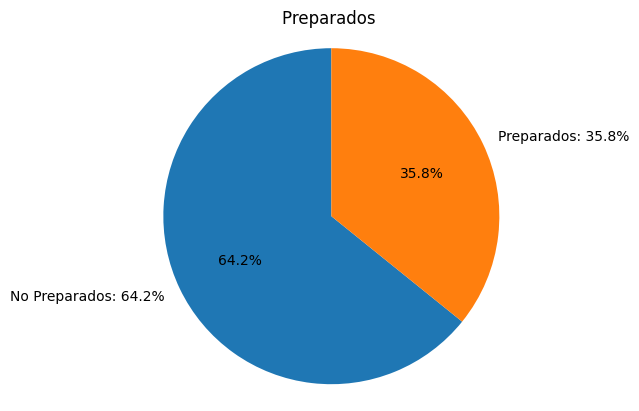

In [89]:
preparados = df['test prep course'].value_counts()
labels = [ 'Preparados: ' + str(round(x * 1.0 / preparados.sum() * 100.0, 2)) + '%' for x in preparados ]
labels[0] = 'No ' + labels[0]
plt.pie(preparados, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Preparados ')
plt.axis('equal')
plt.show()

# Justificacion
En el grafico podemos ver el porcentaje de datos en la columna test prep course (prueba preparacion curso, tipo ensayo), hay un 35,8% de alumnos que lo completaron, y un 64,2% de alumnos que no lo hicieron

In [90]:
data_preparados = df[df['test prep course'] == 'completed']
print(data_preparados.shape)

(358, 8)


In [91]:
rango_porcentaje_math = pd.cut(data_preparados['math score'], bins=[0, 20, 40, 60, 80, 100])


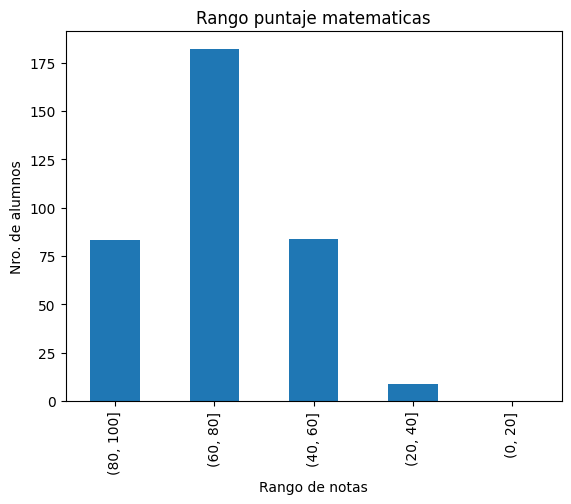

In [92]:
plot = pd.Series(rango_porcentaje_math).value_counts().sort_index(ascending=False).plot(kind='bar', title='Rango puntaje matematicas')
plot.set_xlabel('Rango de notas')
plot.set_ylabel('Nro. de alumnos')
plt.show()

# Justificacion
 En el grafico de barras podemos ver el rango de puntaje de matematicas que va de 0 a 10 hasta 90 a 100 y el numero de alumnos dentro de cada rango

In [106]:
rango_porcentaje_science = pd.cut(data_preparados['science score'],  bins=[0, 20, 40, 60, 80, 100])


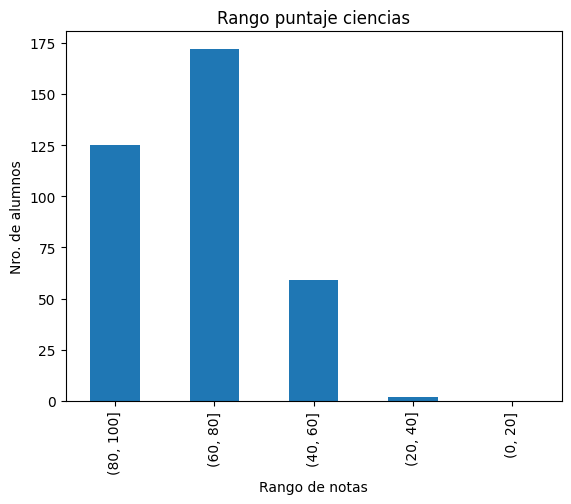

In [107]:
plot = pd.Series(rango_porcentaje_science).value_counts().sort_index(ascending=False).plot(kind='bar', title='Rango puntaje ciencias')
plot.set_xlabel('Rango de notas')
plot.set_ylabel('Nro. de alumnos')
plt.show()

#Justificación
En el anterior grafico de barras podemos ver el rango de puntaje de ciencias que va de 0 a 10 hasta 90 a 100 y el número de alumnos dentro de cada rango

In [109]:
rango_porcentaje_eng = pd.cut(data_preparados['english score'],  bins=[0, 20, 40, 60, 80, 100])
rango_porcentaje_eng = rango_porcentaje_eng.cat.reorder_categories(rango_porcentaje_eng.cat.categories[::-1], ordered=True)

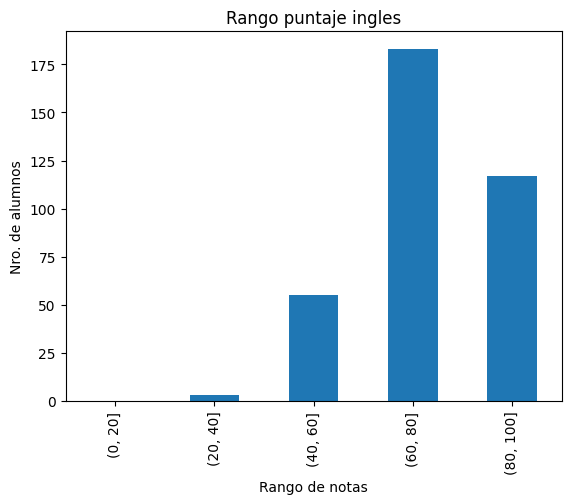

In [110]:
plot = pd.Series(rango_porcentaje_eng).value_counts().sort_index(ascending=False).plot(kind='bar', title='Rango puntaje ingles')
plot.set_xlabel('Rango de notas')
plot.set_ylabel('Nro. de alumnos')
plt.show()

#Justificación
En el anterior grafico de barras podemos ver el rango de puntaje de inglés que va de 0 a 10 hasta 90 a 100 y el número de alumnos dentro de cada rango

In [97]:
TipoAlmuerzo = (df[df['lunch'] == 'free/reduced']['lunch'].count() * 1.0 / df['lunch'].count()) * 100.0
print("El procentaje de alumnos que almuerzan gratuitamente es {0:.2f}%".format(TipoAlmuerzo))

El procentaje de alumnos que almuerzan gratuitamente es 35.50%


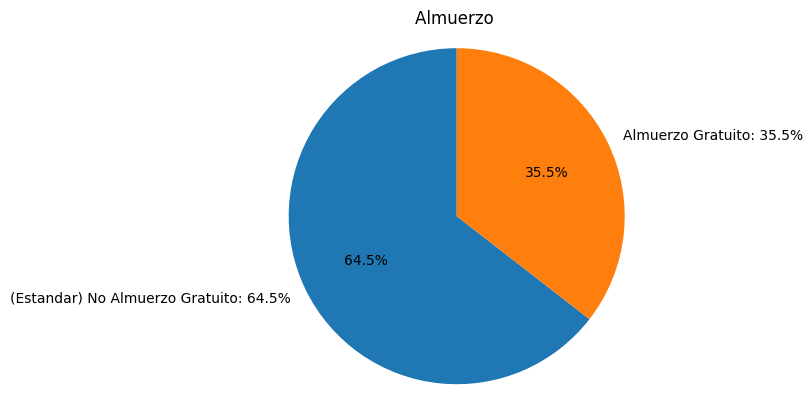

In [98]:
Almuerzo = df['lunch'].value_counts()
labels = [
    'Almuerzo Gratuito: ' + str(round(x * 1.0 / Almuerzo.sum() * 100.0, 2)) + '%' for x in Almuerzo
          ]
labels[0] = '(Estandar) No ' + labels[0]
plt.pie(Almuerzo, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Almuerzo ')
plt.axis('equal')
plt.show()

# Justificacion
En el grafico podemos ver el porcentaje de datos en la columna lunch (tipo de almuerzo del alumno), hay un 35,5% de alumnos que reciben almuerzo gratuito, y un 64,5% de alumnos que almuerzan de manera estandar.

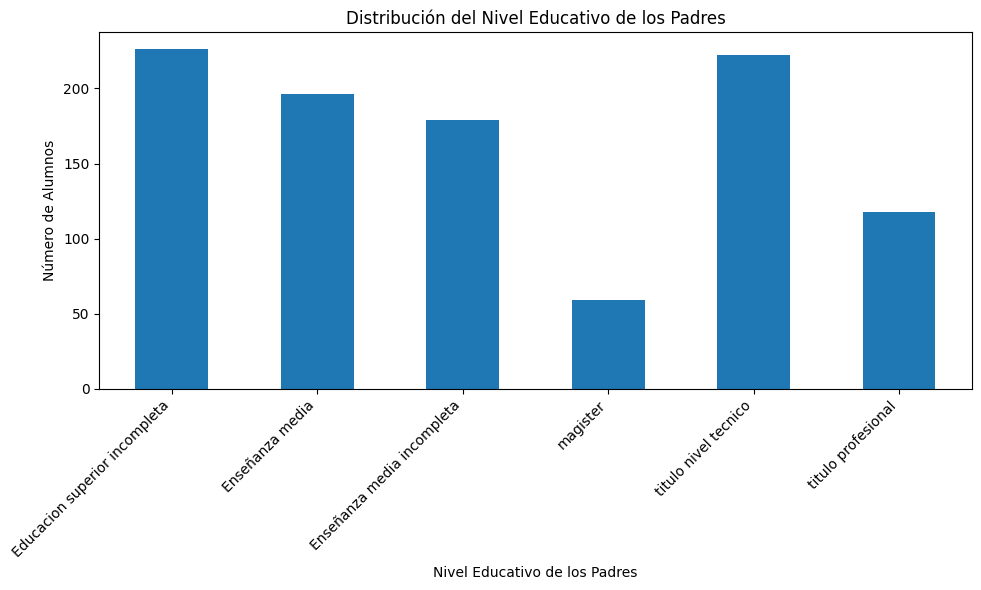

In [99]:
education_level_mapping = {
    "some high school": "Enseñanza media incompleta",
    "high school": "Enseñanza media",
    "some college": "Educacion superior incompleta",
    "associate's degree": "titulo nivel tecnico",
    "bachelor's degree": "titulo profesional",
    "master's degree": "magister"
}

df_spanish_education = df.copy()
df_spanish_education['parental education level'] = df_spanish_education['parental education level'].replace(education_level_mapping)

plt.figure(figsize=(10, 6))
df_spanish_education['parental education level'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución del Nivel Educativo de los Padres')
plt.xlabel('Nivel Educativo de los Padres')
plt.ylabel('Número de Alumnos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Justificacion
En el gráfico comparamos el numero de alumnos y el nivel educacional de los padres, donde encontramos que la los padres de la mayoria de los alumnos no completaron la educacion superior mientras que la minoria tiene a sus padres con un magister.

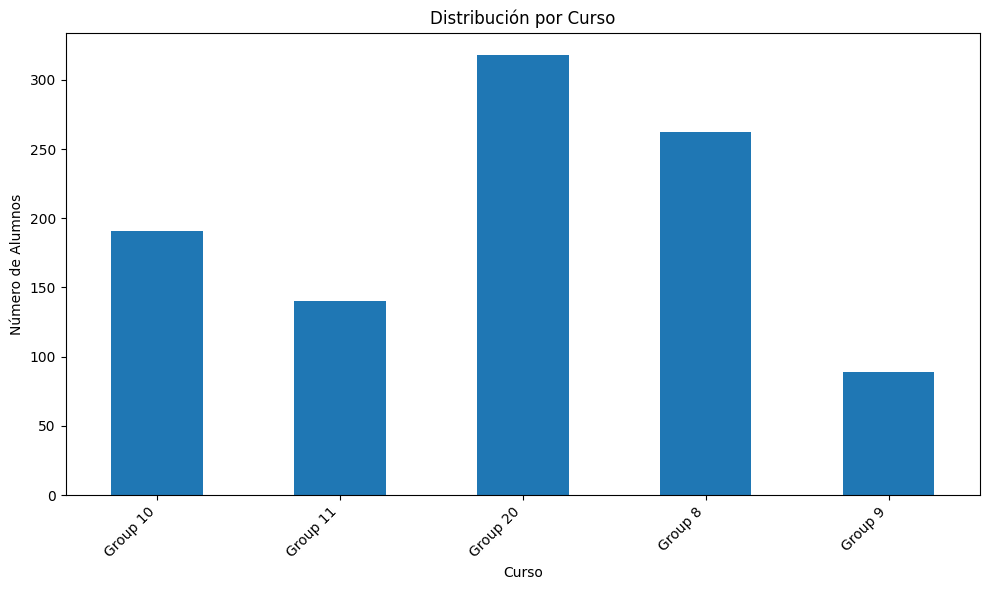

In [100]:
plt.figure(figsize=(10, 6))
df['race/group'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución por Curso')
plt.xlabel('Curso')
plt.ylabel('Número de Alumnos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Justificacion
En el gráfico comparamos el numero de alumnos y el nivel educacional de los padres, donde encontramos que la los padres de la mayoria de los alumnos no completaron la educacion superior mientras que la minoria tiene a sus padres con un magister.

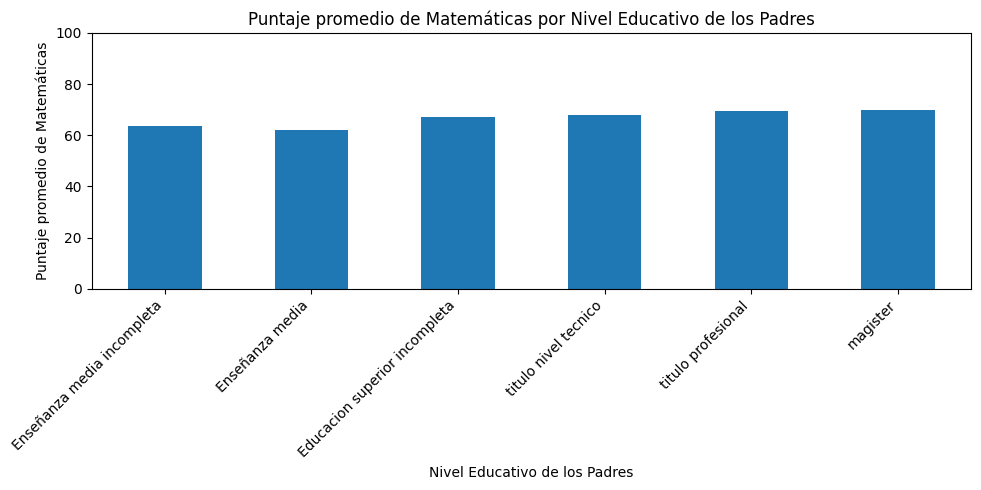

In [111]:
df_spanish_education = df.copy()
df_spanish_education['parental education level'] = df_spanish_education['parental education level'].replace(education_level_mapping)

rango_porcentaje_math = df_spanish_education.groupby('parental education level')['math score'].mean().reindex(
    ['Enseñanza media incompleta',
    'Enseñanza media',
    'Educacion superior incompleta',
    'titulo nivel tecnico',
    'titulo profesional',
    'magister']
)

plt.figure(figsize=(10, 5))
rango_porcentaje_math.plot(kind='bar')
plt.title('Puntaje promedio de Matemáticas por Nivel Educativo de los Padres')
plt.xlabel('Nivel Educativo de los Padres')
plt.ylabel('Puntaje promedio de Matemáticas')
plt.ylim(0, 100) # Set y-axis limit from 0 to 100
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Justificación

En este grafico se compara el puntaje promedio en matematicas junto con la variable de hasta que educación llegaron los padres del alumno. Podemos apreciar que aquellos que sus padres llegaron solo a la educación media o no terminaron esta misma tienen menos puntaje que los que tienen un titulo tecnico o enseñanza superior incompleta.

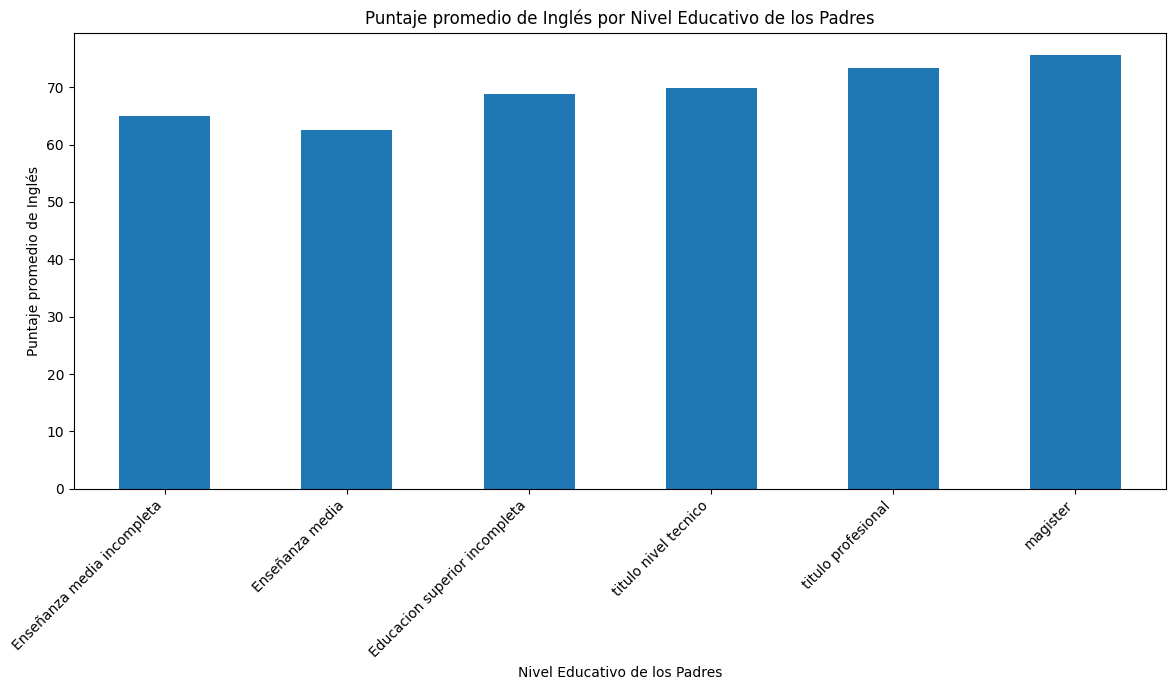

In [102]:
education_level_mapping = {
    "some high school": "Enseñanza media incompleta",
    "high school": "Enseñanza media",
    "some college": "Educacion superior incompleta",
    "associate's degree": "titulo nivel tecnico",
    "bachelor's degree": "titulo profesional",
    "master's degree": "magister"
}

df_spanish_education = df.copy()
df_spanish_education['parental education level'] = df_spanish_education['parental education level'].replace(education_level_mapping)

average_math_score_by_education = df_spanish_education.groupby('parental education level')['english score'].mean().reindex([
    'Enseñanza media incompleta',
    'Enseñanza media',
    'Educacion superior incompleta',
    'titulo nivel tecnico',
    'titulo profesional',
    'magister'
])

plt.figure(figsize=(12, 7))
average_math_score_by_education.plot(kind='bar')
plt.title('Puntaje promedio de Inglés por Nivel Educativo de los Padres')
plt.xlabel('Nivel Educativo de los Padres')
plt.ylabel('Puntaje promedio de Inglés')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Justificación

En este grafico se realizan las mismas operaciones que en los graficos de arriba, pero en esta ocasión comparamos con el puntaje en la prueba de Inglés. Es importante señalar que la diferencia aca es mucho más drastica que comparando los puntajes en matematicas, con la categoria de Enseñanza Media contando con una diferencia de más de 10 puntos en promedio.

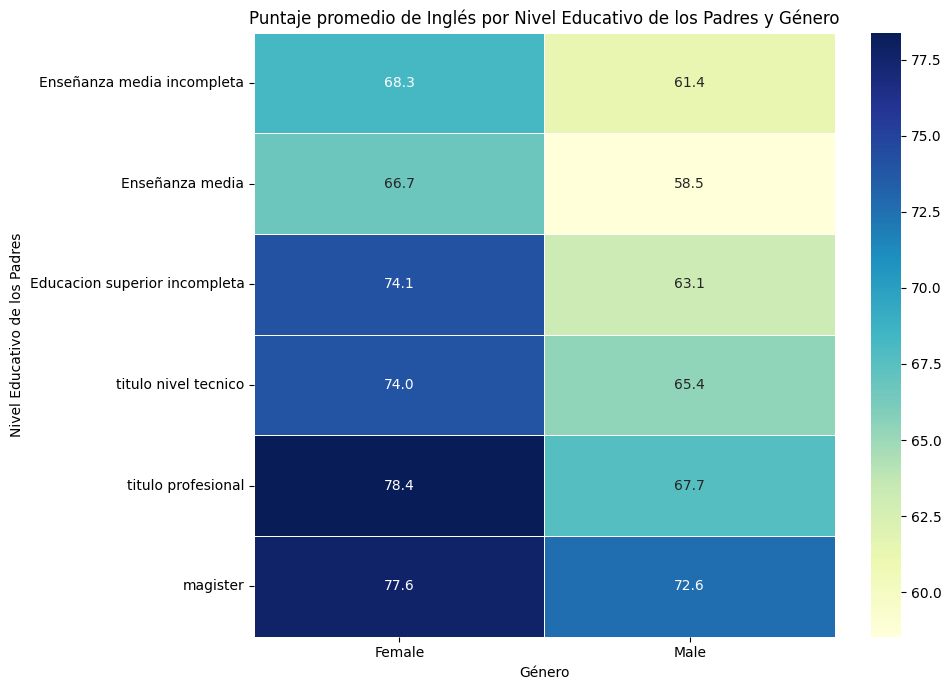

In [103]:
import seaborn as sns

# Ensure the order of education levels for consistency
education_order = [
    'Enseñanza media incompleta',
    'Enseñanza media',
    'Educacion superior incompleta',
    'titulo nivel tecnico',
    'titulo profesional',
    'magister'
]

heatmap_data = df_spanish_education.groupby(['parental education level', 'gender'])['english score'].mean().unstack()

heatmap_data = heatmap_data.reindex(education_order)

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
plt.title('Puntaje promedio de Inglés por Nivel Educativo de los Padres y Género')
plt.xlabel('Género')
plt.ylabel('Nivel Educativo de los Padres')
plt.tight_layout()
plt.show()

# Justificación

Este heatmap visualiza el puntaje promedio de Inglés desglosado por el nivel educativo de los padres y el género del estudiante. Podemos observar cómo la combinación de estos dos factores influye en el rendimiento en inglés, ofreciendo una perspectiva más detallada que el gráfico de barras anterior.

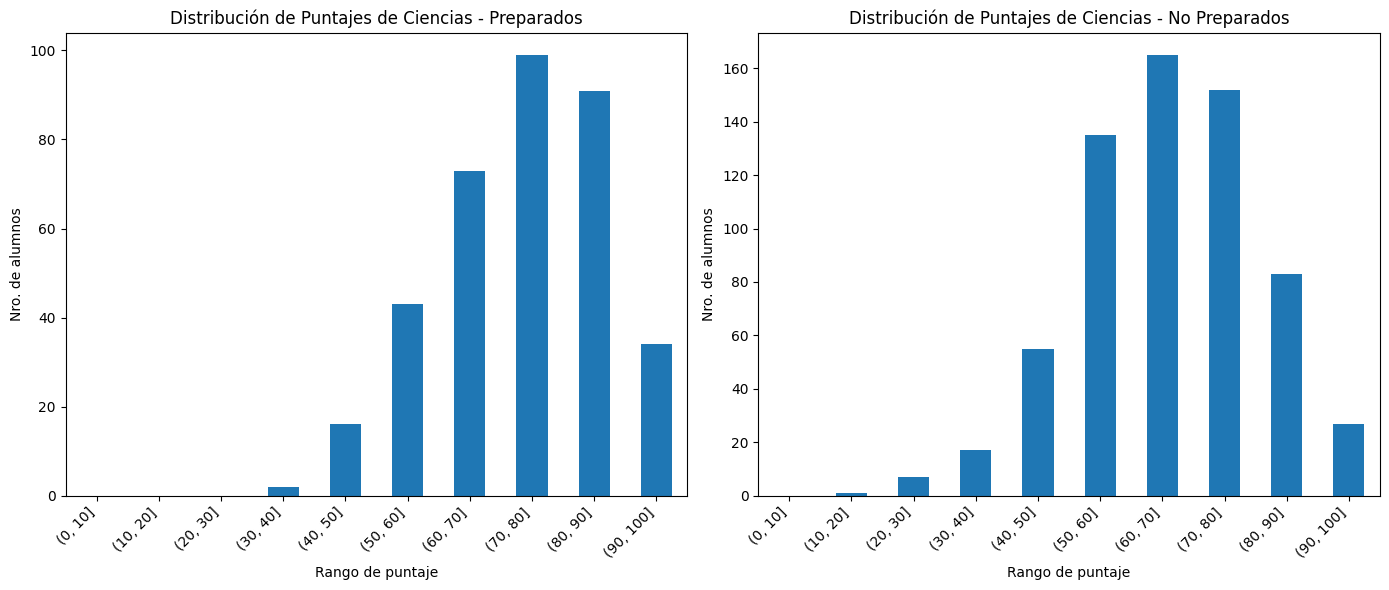

In [104]:
plt.figure(figsize=(14, 6))

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

plt.subplot(1, 2, 1)
completed_scores = df[df['test prep course'] == 'completed']['science score']
completed_rango = pd.cut(completed_scores, bins=bins)
completed_plot_data = pd.Series(completed_rango).value_counts().sort_index()
completed_plot_data.plot(kind='bar', title='Distribución de Puntajes de Ciencias - Preparados')
plt.xlabel('Rango de puntaje')
plt.ylabel('Nro. de alumnos')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
none_scores = df[df['test prep course'] == 'none']['science score']
none_rango = pd.cut(none_scores, bins=bins)
none_plot_data = pd.Series(none_rango).value_counts().sort_index()
none_plot_data.plot(kind='bar', title='Distribución de Puntajes de Ciencias - No Preparados')
plt.xlabel('Rango de puntaje')
plt.ylabel('Nro. de alumnos')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# **Justificación**
Estos 2 graficos de barras visualizan el puntaje promedio en Ciencias, separando entre los que realizaron el ensayo de prueba y los que no. Podemos notar que aquellos estudiantes que se dieron el tiempo de hacer el ensayo tienen mejor puntaje que los que no, con puntajes menores a 50 siendo muy poco comunes en el grupo de los que hicieron el ensayo.

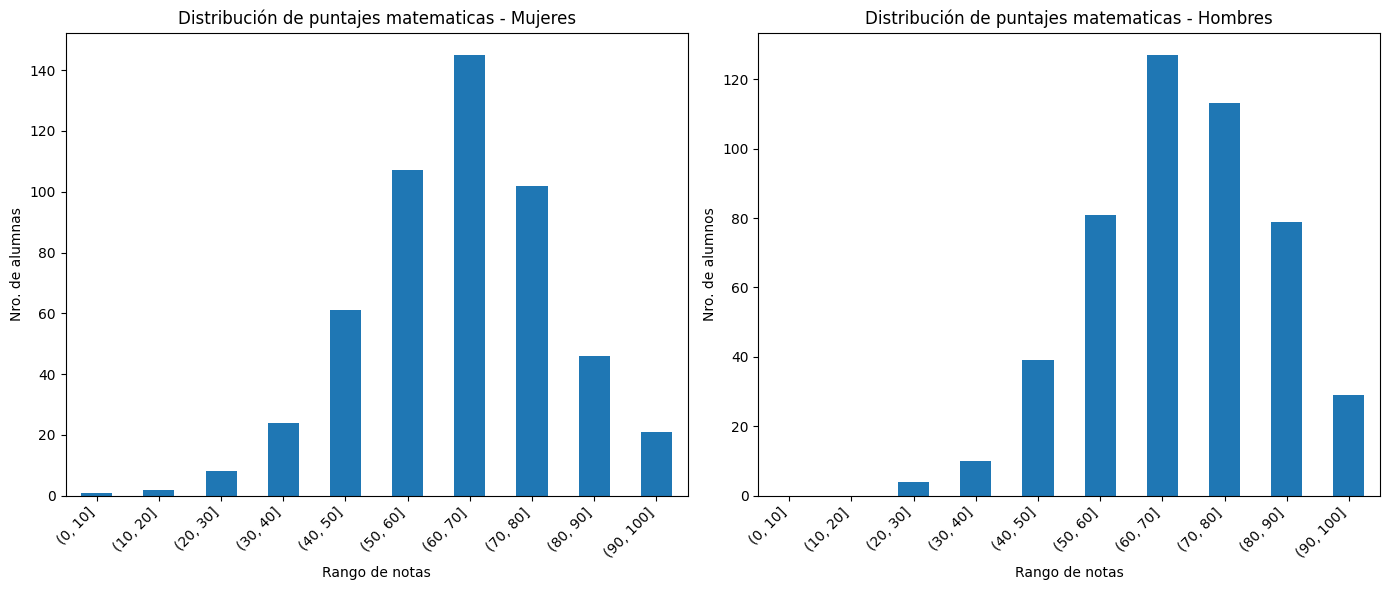

In [105]:
plt.figure(figsize=(14, 6))

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

plt.subplot(1, 2, 1)
female_scores = df[df['gender'] == 'Female']['math score']
female_rango = pd.cut(female_scores, bins=bins)
female_plot_data = pd.Series(female_rango).value_counts().sort_index()
female_plot_data.plot(kind='bar', title=f'{"Distribución de puntajes matematicas"} - Mujeres')
plt.xlabel('Rango de notas')
plt.ylabel('Nro. de alumnas')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
male_scores = df[df['gender'] == 'Male']['math score']
male_rango = pd.cut(male_scores, bins=bins)
male_plot_data = pd.Series(male_rango).value_counts().sort_index()
male_plot_data.plot(kind='bar', title=f'{"Distribución de puntajes matematicas"} - Hombres')
plt.xlabel('Rango de notas')
plt.ylabel('Nro. de alumnos')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Justificación

Estos gráficos de barras muestran la distribución de puntajes en intervalos de 10 puntos para la asignatura de Matematicas, separados por género. Esto permite una comparación detallada del rendimiento entre hombres y mujeres, y ayuda a identificar en qué rangos de puntaje se concentra la mayoría de los estudiantes de cada género.